# Vessel Detection Inference

This notebook provides simplified inference functionality for PyNAS trained vessel detection models.

In [1]:
"""Simplified inference script for PyNAS trained vessel detection model."""

import os
import sys
sys.path.append('..')
from pathlib import Path
from typing import Optional, Dict

import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets.RawVessels.loader import RawVesselsDataModule

/Data_large/marine/PythonProjects/OtherProjects/lpl-PyNas/.venv/lib/python3.9/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
class VesselInference:
    """Simplified vessel detection inference class."""
    
    def __init__(self, model_path: str, device: Optional[str] = None) -> None:
        """
        Initialize the inference class.
        
        Args:
            model_path (str): Path to the TorchScript model file
            device (Optional[str]): Device to run inference on. If None, auto-detect
        """
        self.model_path = Path(model_path)
        assert self.model_path.exists(), f'Model file not found: {model_path}'
        
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') if device is None else torch.device(device)
        print(f'Using device: {self.device}')
        
        self.model = torch.jit.load(self.model_path, map_location=self.device)
        self.model.eval()
        print(f'Model loaded from {self.model_path}')
    
    def predict(self, input_tensor: torch.Tensor, threshold: float = 0.5) -> np.ndarray:
        """
        Perform inference on input tensor.
        
        Args:
            input_tensor (torch.Tensor): Input tensor (B, C, H, W)
            threshold (float): Threshold for binary classification
            
        Returns:
            np.ndarray: Binary prediction masks (B, H, W)
        """
        input_tensor = input_tensor.to(self.device)
        
        with torch.no_grad():
            predictions = self.model(input_tensor)
        
        # Handle different output formats
        if predictions.shape[1] == 2:
            vessel_probs = predictions[:, 1, :, :]
        else:
            vessel_probs = predictions.squeeze(1)
        
        # Apply sigmoid if needed
        if vessel_probs.min() < 0 or vessel_probs.max() > 1:
            vessel_probs = torch.sigmoid(vessel_probs)
        
        binary_masks = (vessel_probs.cpu().numpy() > threshold).astype(np.uint8)
        return binary_masks
    
    def calculate_metrics(self, predictions: np.ndarray, targets: np.ndarray) -> Dict[str, float]:
        """
        Calculate basic evaluation metrics.
        
        Args:
            predictions (np.ndarray): Binary prediction masks
            targets (np.ndarray): Ground truth masks
            
        Returns:
            Dict[str, float]: Dictionary of metrics
        """
        pred_flat = predictions.flatten()
        target_flat = targets.flatten()
        
        tp = np.sum((pred_flat == 1) & (target_flat == 1))
        fp = np.sum((pred_flat == 1) & (target_flat == 0))
        fn = np.sum((pred_flat == 0) & (target_flat == 1))
        tn = np.sum((pred_flat == 0) & (target_flat == 0))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        
        return {'precision': precision, 'recall': recall, 'f1_score': f1_score, 'iou': iou}
    
    def visualize(self, image: np.ndarray, prediction: np.ndarray, target: Optional[np.ndarray] = None) -> None:
        """
        Visualize inference results.
        
        Args:
            image (np.ndarray): Input image (H, W)
            prediction (np.ndarray): Prediction mask (H, W)
            target (Optional[np.ndarray]): Ground truth mask (H, W)
        """
        cols = 3 if target is not None else 2
        fig, axes = plt.subplots(1, cols, figsize=(5 * cols, 5))
        
        if cols == 2:
            axes = [axes[0], axes[1]]
        
        axes[0].imshow(image, cmap='gray')
        axes[0].set_title('Input Image')
        axes[0].axis('off')
        
        axes[1].imshow(prediction, cmap='gray')
        axes[1].set_title('Prediction')
        axes[1].axis('off')
        
        if target is not None:
            axes[2].imshow(target, cmap='gray')
            axes[2].set_title('Ground Truth')
            axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

In [3]:
# Configuration
model_path = '/Data_large/marine/PythonProjects/OtherProjects/lpl-PyNas/models_traced/generation_2/model_and_architecture_13.pt'
data_dir = '/Data_large/marine/PythonProjects/OtherProjects/lpl-PyNas/data/TASI/DataSAR_real_refined'
batch_size = 1
threshold = 0.5

# Initialize inference
inferencer = VesselInference(model_path)

Using device: cuda
Model loaded from /Data_large/marine/PythonProjects/OtherProjects/lpl-PyNas/models_traced/generation_2/model_and_architecture_13.pt


In [4]:
# Setup data module
data_module = RawVesselsDataModule(root_dir=data_dir, batch_size=batch_size)
data_module.setup()

print(f'Data module setup complete:')
print(f'  Input shape: {data_module.input_shape}')
print(f'  Number of classes: {data_module.num_classes}')
print(f'  Test dataset size: {len(data_module.test_dataset)}')

Data module setup complete:
  Input shape: torch.Size([2, 1200, 1200])
  Number of classes: 2
  Test dataset size: 289


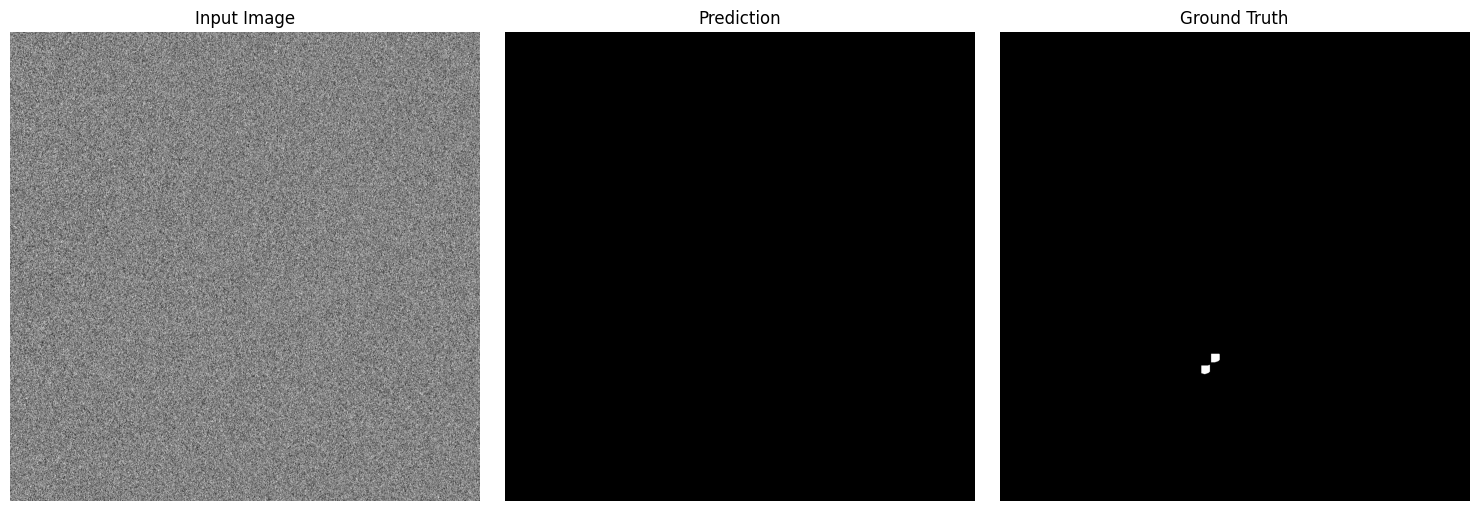

Metrics: {'precision': 0.0, 'recall': 0.0, 'f1_score': 0.0, 'iou': 0.0}


In [7]:
# Get a test sample and run inference
test_loader = data_module.test_dataloader()
images, targets = next(iter(test_loader))

# Run inference
predictions = inferencer.predict(images, threshold=threshold)

# Extract data for visualization
image = images[0, 0].numpy()  # First image, first channel
prediction = predictions[0]   # First prediction
target = targets[0, 1].numpy() if targets.shape[1] == 2 else targets[0].squeeze().numpy()

# Visualize results
inferencer.visualize(image, prediction, target)

# Calculate and display metrics
metrics = inferencer.calculate_metrics(predictions, target.reshape(1, *target.shape))
print(f'Metrics: {metrics}')